# Visualizing statistical relationships

We will discuss three seaborn functions in this tutorial. The one we will use most is relplot(). This is a figure-level function for visualizing statistical relationships using two common approaches: scatter plots and line plots. relplot() combines a FacetGrid with one of two axes-level functions:

scatterplot() (with kind="scatter"; the default)

lineplot() (with kind="line")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#sns.set_theme(style="darkgrid")

## Relating variables with scatter plots

It represent the joint distribution of two variables using a cloud of points, where each point represents an observation in the dataset.

#### Check Seaborn datasets

Experience the full potential of Seaborn with its built-in datasets. 

Simply call get_dataset_names() to obtain a comprehensive list of all available datasets for you to experiment with.

In [9]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic',
 'anagrams',
 'anagrams',
 'anscombe',
 'anscombe',
 'attention',
 'attention',
 'brain_networks',
 'brain_networks',
 'car_crashes',
 'car_crashes',
 'diamonds',
 'diamonds',
 'dots',
 'dots',
 'dowjones',
 'dowjones',
 'exercise',
 'exercise',
 'flights',
 'flights',
 'fmri',
 'fmri',
 'geyser',
 'geyser',
 'glue',
 'glue',
 'healthexp',
 'healthexp',
 'iris',
 'iris',
 'mpg',
 'mpg',
 'penguins',
 'penguins',
 'planets',
 'planets',
 'seaice',
 'seaice',
 'taxis',
 'taxis',
 'tips',
 'tips',
 'titanic',
 'titanic',
 'anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'plan

In [10]:
tips = sns.load_dataset("tips")

In [11]:
tips.shape

(244, 7)

In [12]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [13]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [14]:
tips.groupby(['smoker'])['smoker'].count()

smoker
Yes     93
No     151
Name: smoker, dtype: int64

In [15]:
tips.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

<Axes: xlabel='total_bill', ylabel='tip'>

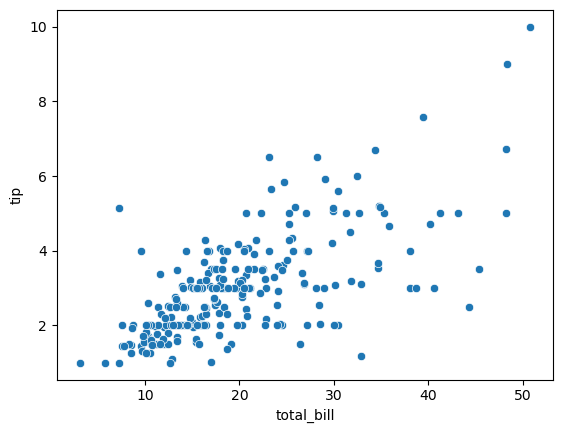

In [16]:
#Method1
sns.scatterplot(x='total_bill',y='tip',data=tips)

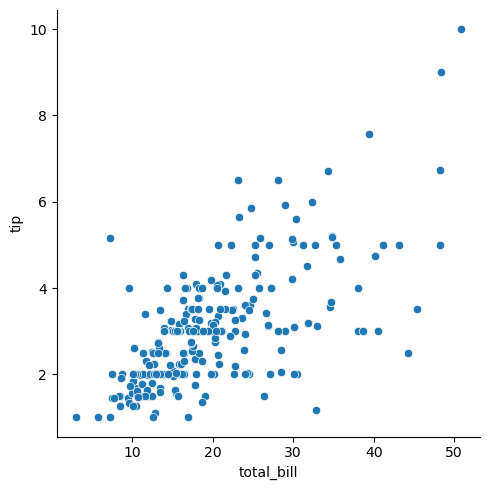

In [17]:
#Method2
sns.relplot(x='total_bill',y='tip',data=tips)

In [18]:
sns.set_theme(style="darkgrid")

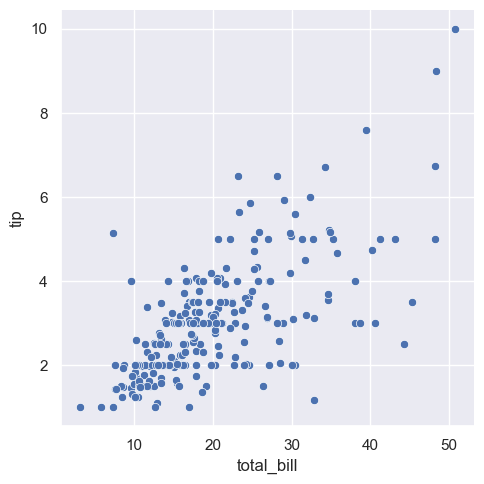

In [19]:
#Method2
sns.relplot(x='total_bill',y='tip',data=tips)

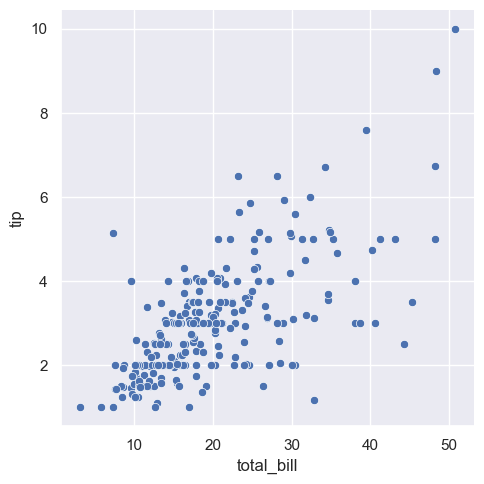

In [21]:
#OR
sns.relplot(x=tips['total_bill'],y=tips['tip'])

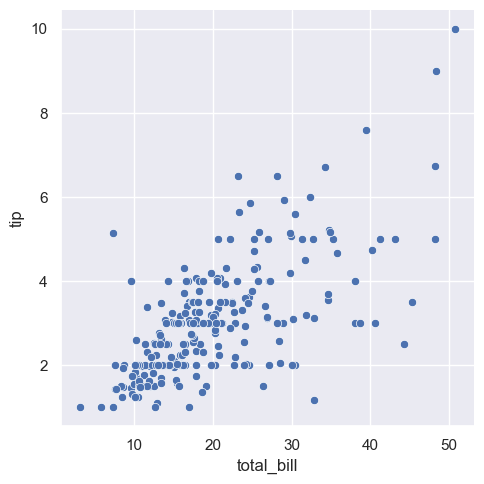

In [22]:
#scatterplot() is the default kind in relplot() (it can also be forced by setting kind="scatter"):
sns.relplot(x='total_bill',y='tip',data=tips, kind='scatter')

#### While the points are plotted in two dimensions, another dimension can be added to the plot by coloring the points according to a third variable. In seaborn, this is referred to as using a “hue semantic”, because the color of the point gains meaning:

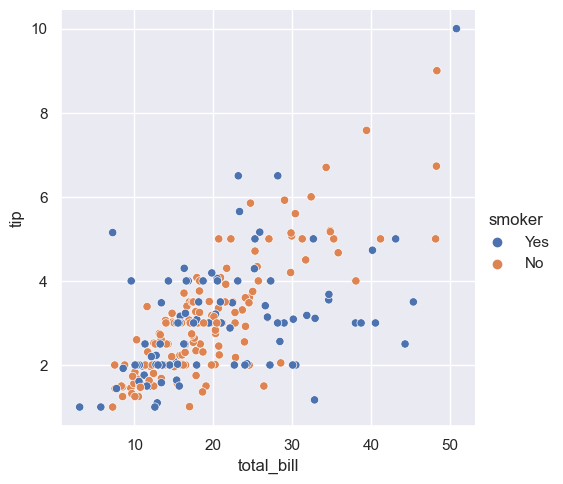

In [26]:
sns.relplot(x='total_bill',y='tip',data=tips,hue='smoker')

#### To emphasize the difference between the classes, and to improve accessibility, you can use a different marker style for each class:

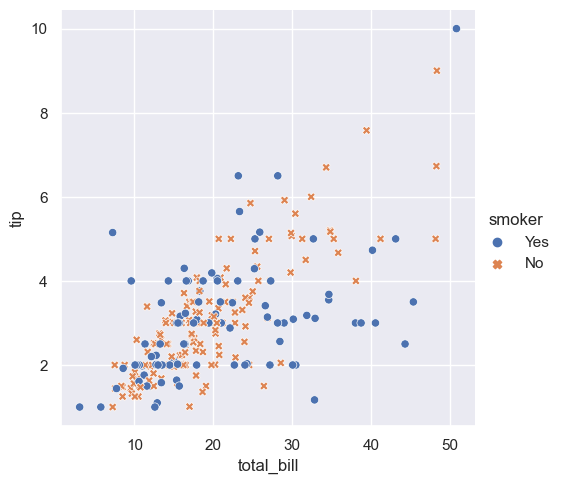

In [29]:
sns.relplot(x='total_bill',y='tip',data=tips,hue='smoker',style='smoker')

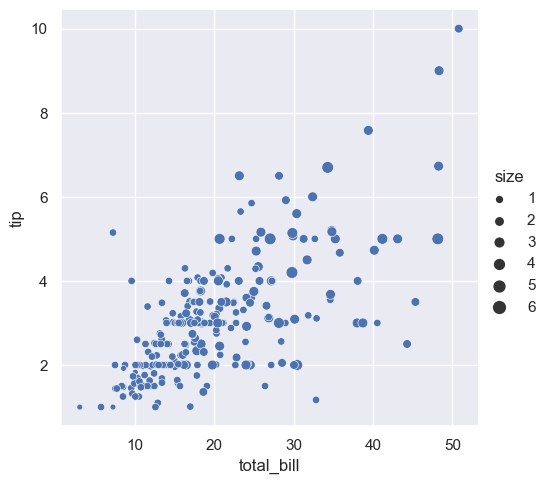

In [30]:
sns.relplot(x='total_bill',y='tip',data=tips,size='size')

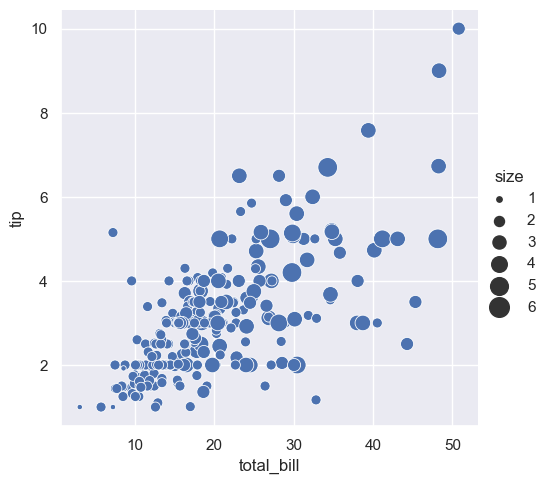

In [31]:
sns.relplot(x='total_bill',y='tip',data=tips,size='size',sizes=(15,200))

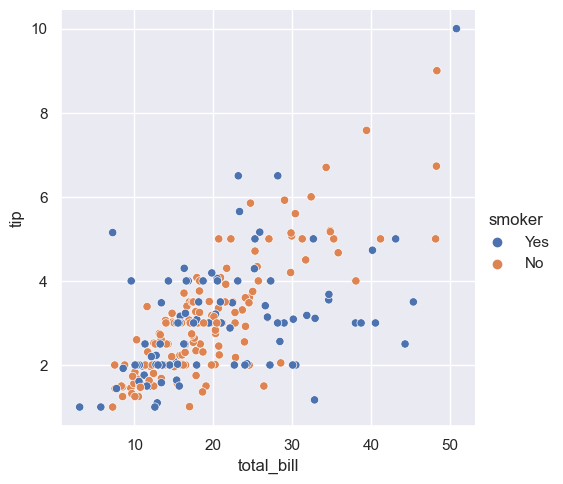

In [33]:
sns.relplot(data=tips, x='total_bill', y='tip',hue='smoker')

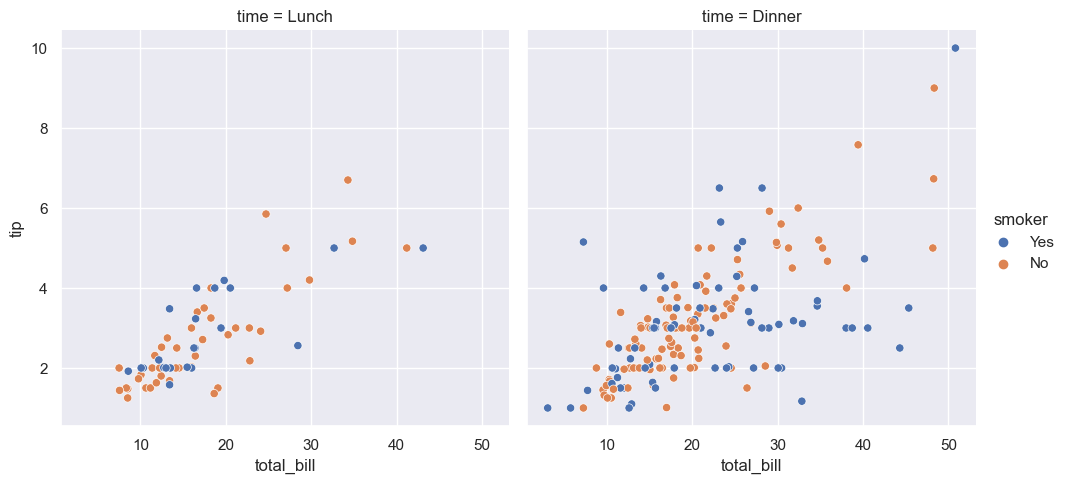

In [34]:
sns.relplot(data=tips, x='total_bill', y='tip',hue='smoker', col='time')

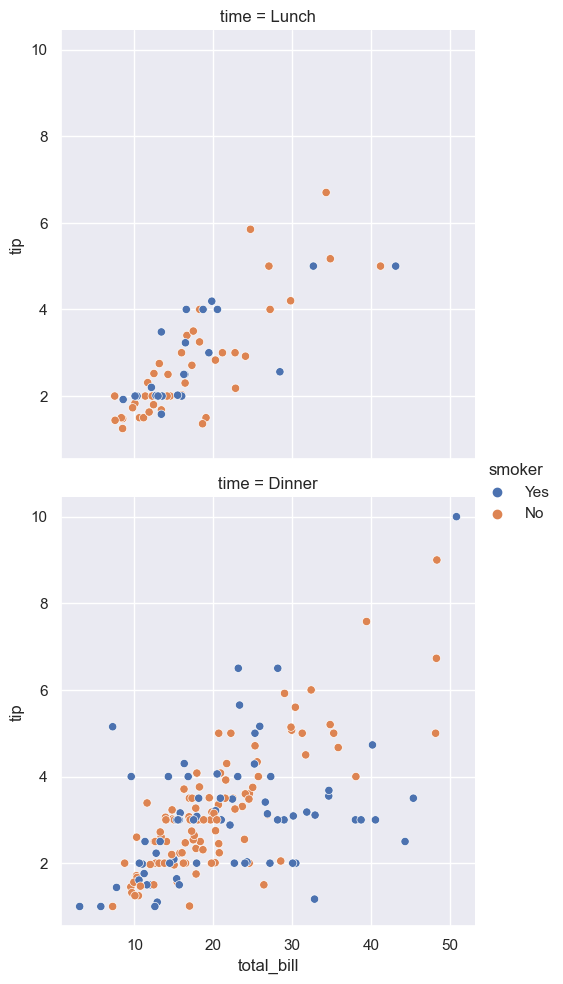

In [35]:
sns.relplot(data=tips, x='total_bill', y='tip',hue='smoker', row='time')

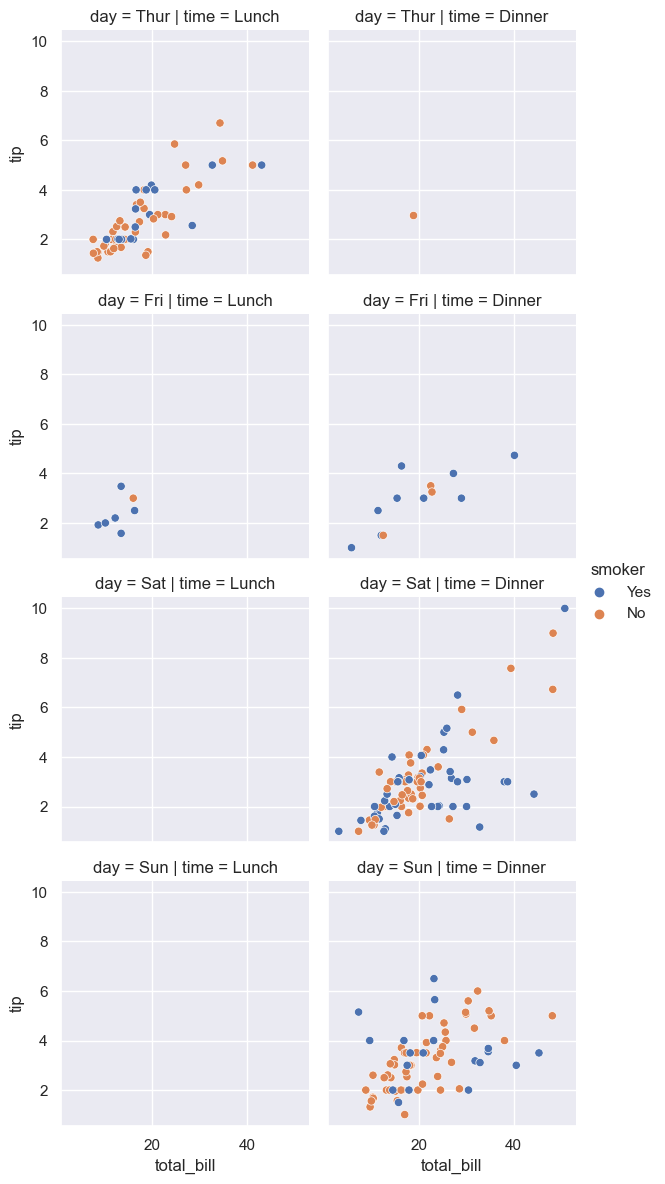

In [36]:
sns.relplot(data=tips, x='total_bill', y='tip',hue='smoker', col='time', row='day', height=3)

In [37]:
tips.groupby(['day','time']).count()

total_bill  tip  sex  smoker  size
day  time                                      
Thur Lunch           61   61   61      61    61
     Dinner           1    1    1       1     1
Fri  Lunch            7    7    7       7     7
     Dinner          12   12   12      12    12
Sat  Lunch            0    0    0       0     0
     Dinner          87   87   87      87    87
Sun  Lunch            0    0    0       0     0
     Dinner          76   76   76      76    76

### Line Plots

Scatter plots are highly effective, but there is no universally optimal type of visualisation. Instead, the visual representation should be adapted for the specifics of the dataset and to the question you are trying to answer with the plot.

With some datasets, you may want to understand changes in one variable as a function of time, or a similarly continuous variable. In this situation, a good choice is to draw a line plot.

In [47]:
dowjones = sns.load_dataset('dowjones')

In [49]:
dowjones.shape

(649, 2)

In [51]:
dowjones.head()

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45


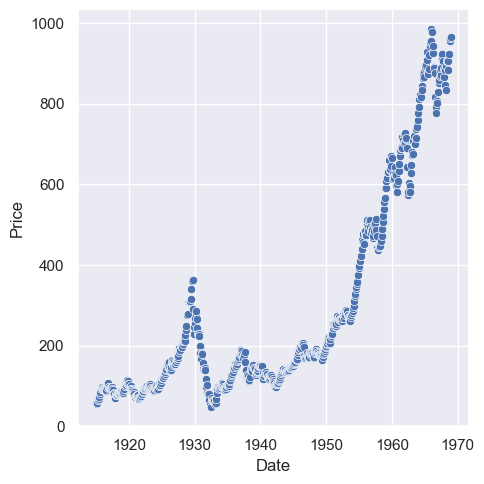

In [53]:
sns.relplot(x='Date',y='Price',data=dowjones)

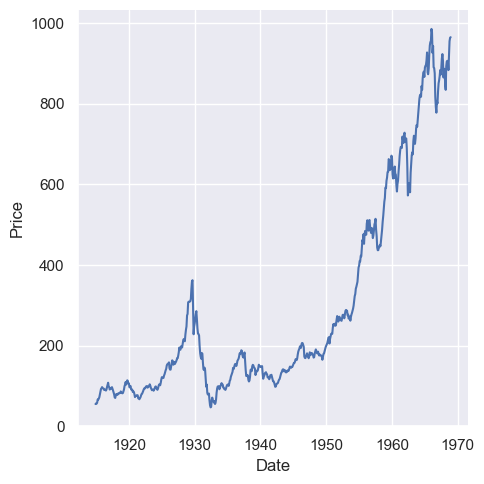

In [54]:
sns.relplot(x='Date',y='Price',data=dowjones, kind='line')

### Aggregation and representing uncertainty

More complex datasets will have multiple measurements for the same value of the x variable. The default behavior in seaborn is to aggregate the multiple measurements at each x value by plotting the mean and the 95% confidence interval around the mean

In [57]:
fmri = sns.load_dataset('fmri')

In [59]:
fmri.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


In [60]:
fmri.groupby('subject')['subject'].count()

subject
s0     76
s1     76
s10    76
s11    76
s12    76
s13    76
s2     76
s3     76
s4     76
s5     76
s6     76
s7     76
s8     76
s9     76
Name: subject, dtype: int64

In [62]:
fmri.shape

(1064, 5)

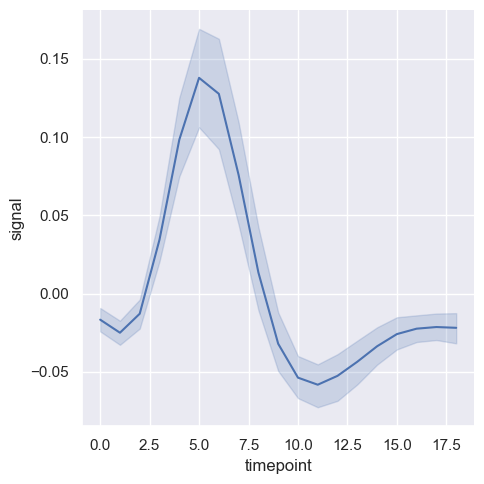

In [63]:
sns.relplot(x='timepoint',y='signal',data=fmri,kind='line')

The confidence intervals are computed using bootstrapping, which can be time-intensive for larger datasets. It’s therefore possible to disable them:

<Axes: xlabel='timepoint', ylabel='signal'>

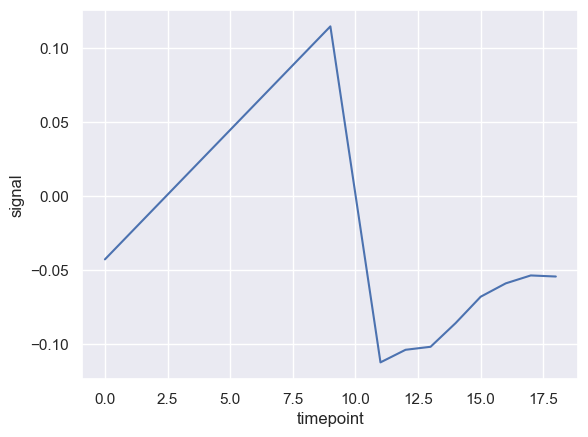

In [69]:
sns.lineplot(x='timepoint',y='signal',data=fmri.head(100),err_style=None)

Another good option, especially with larger data, is to represent the spread of the distribution at each timepoint by plotting the standard deviation instead of a confidence interval:

In [73]:
fmri.nunique()

subject        14
timepoint      19
event           2
region          2
signal       1064
dtype: int64

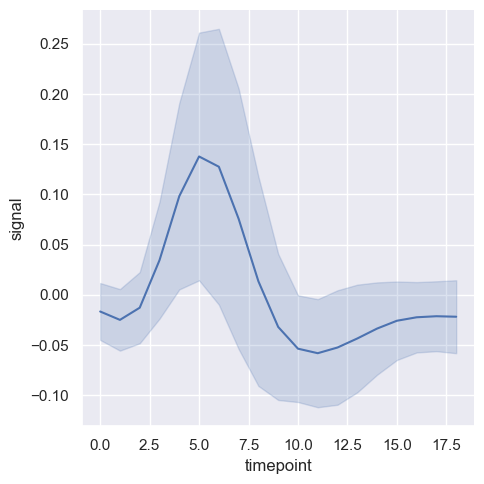

In [78]:
sns.relplot(data=fmri,kind='line',x='timepoint',y='signal', errorbar='sd')

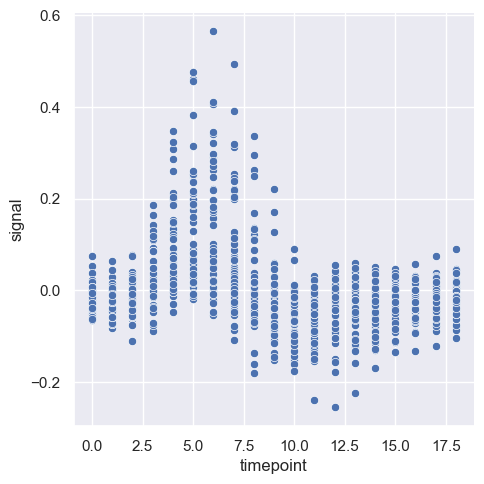

In [80]:
sns.relplot(data=fmri, kind='scatter',x='timepoint',y='signal')

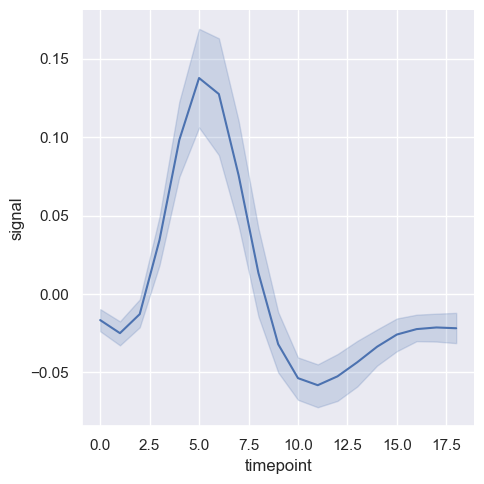

In [82]:
sns.relplot(data=fmri, kind='line',x='timepoint',y='signal')

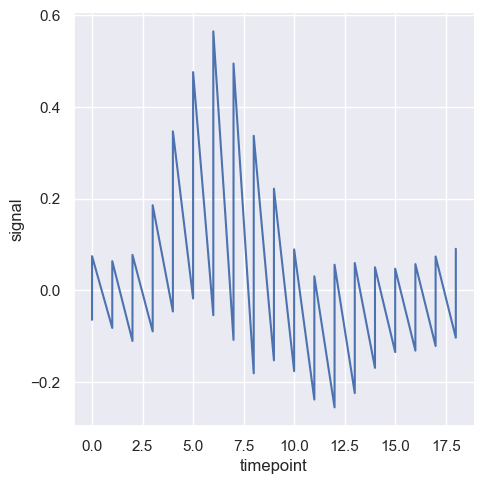

In [84]:
sns.relplot(data=fmri, kind='line',x='timepoint',y='signal',estimator = None)

## Plotting subsets of data with semantic mappings

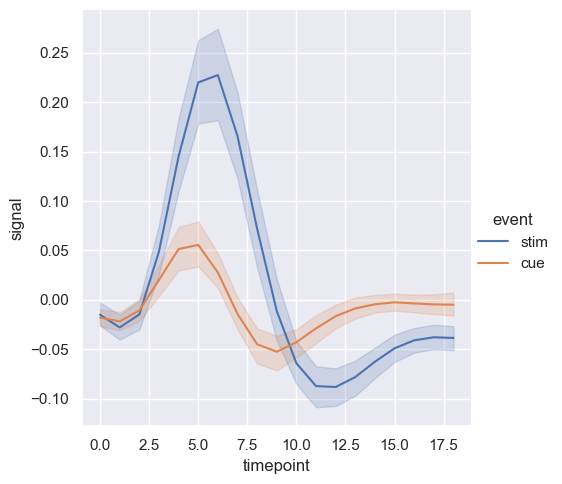

In [87]:
sns.relplot(data=fmri,kind='line',x='timepoint',y='signal',hue='event')

In [89]:
fmri.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


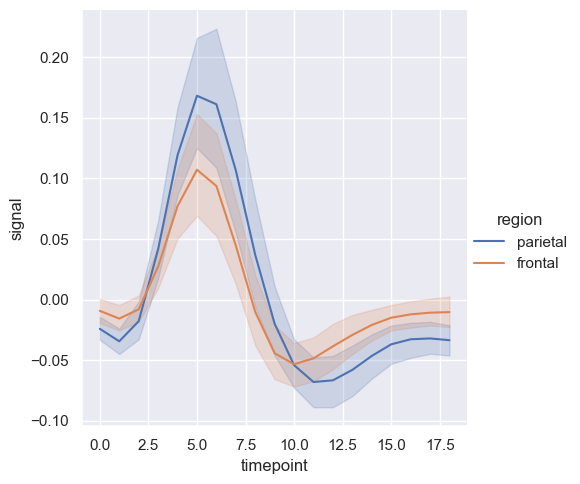

In [91]:
sns.relplot(data=fmri,kind='line',x='timepoint',y='signal',hue='region')

In [93]:
fmri.region.unique()

array(['parietal', 'frontal'], dtype=object)

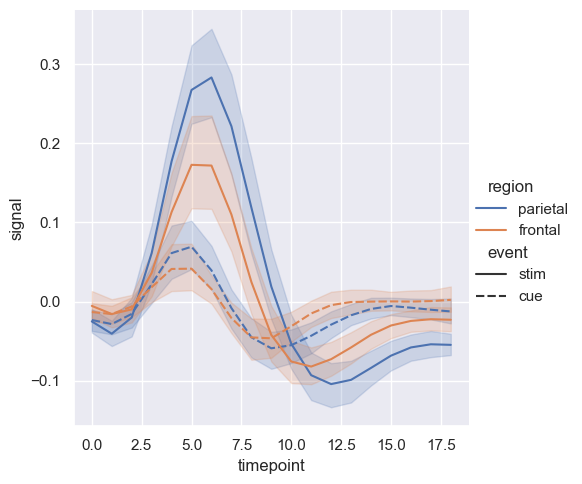

In [95]:
sns.relplot(data=fmri,kind='line',x='timepoint',y='signal',hue='region',style='event')

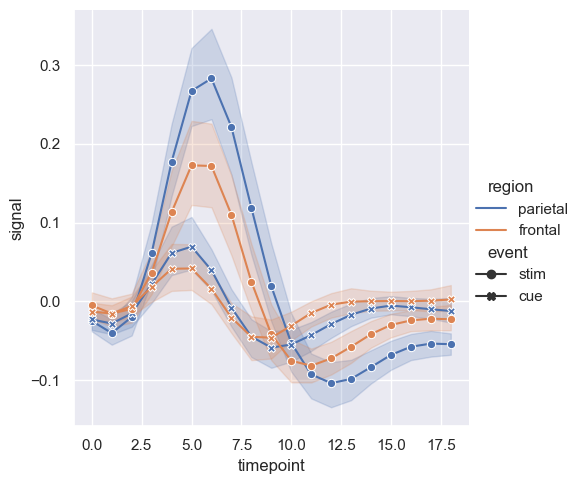

In [97]:
sns.relplot(
    data=fmri, kind="line",
    x="timepoint", y="signal", hue="region", style="event",
    dashes=False, markers=True,
)

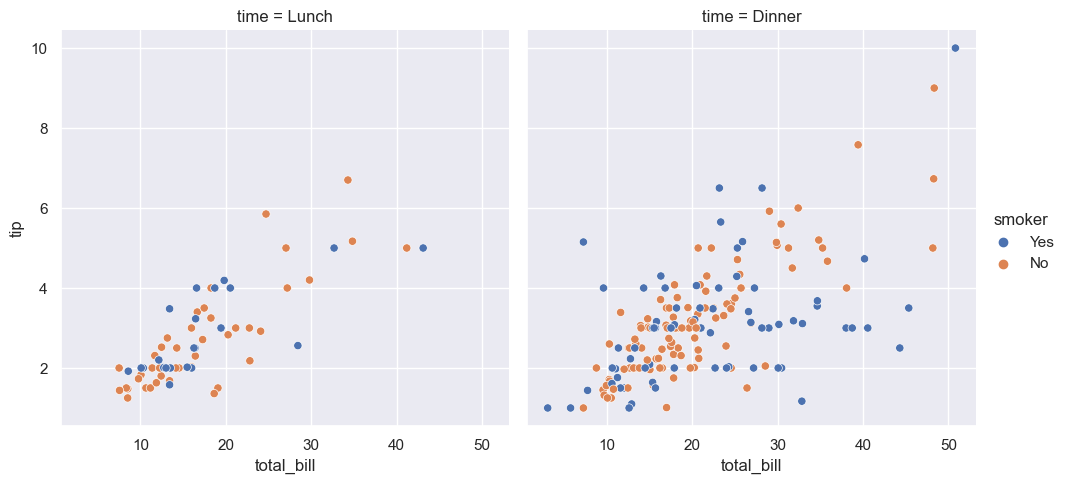

In [99]:
sns.relplot(
    data=tips,
    x="total_bill", y="tip", hue="smoker", col="time",
)

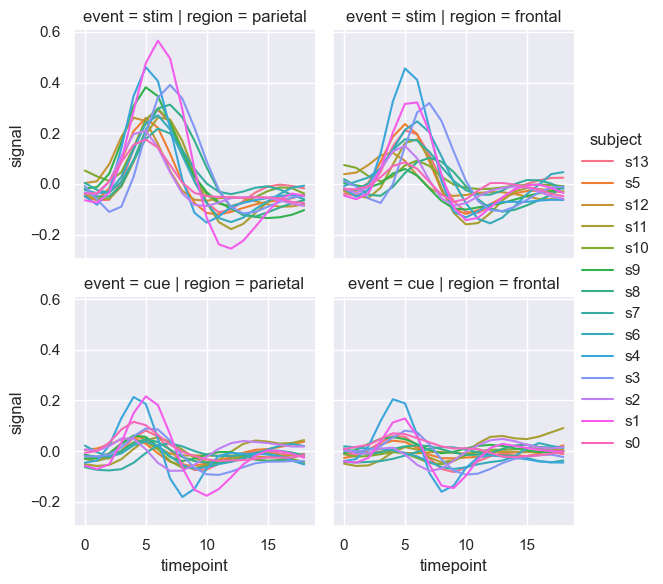

In [101]:
sns.relplot(
    data=fmri, kind="line",
    x="timepoint", y="signal", hue="subject",
    col="region", row="event", height=3,
    estimator=None
)

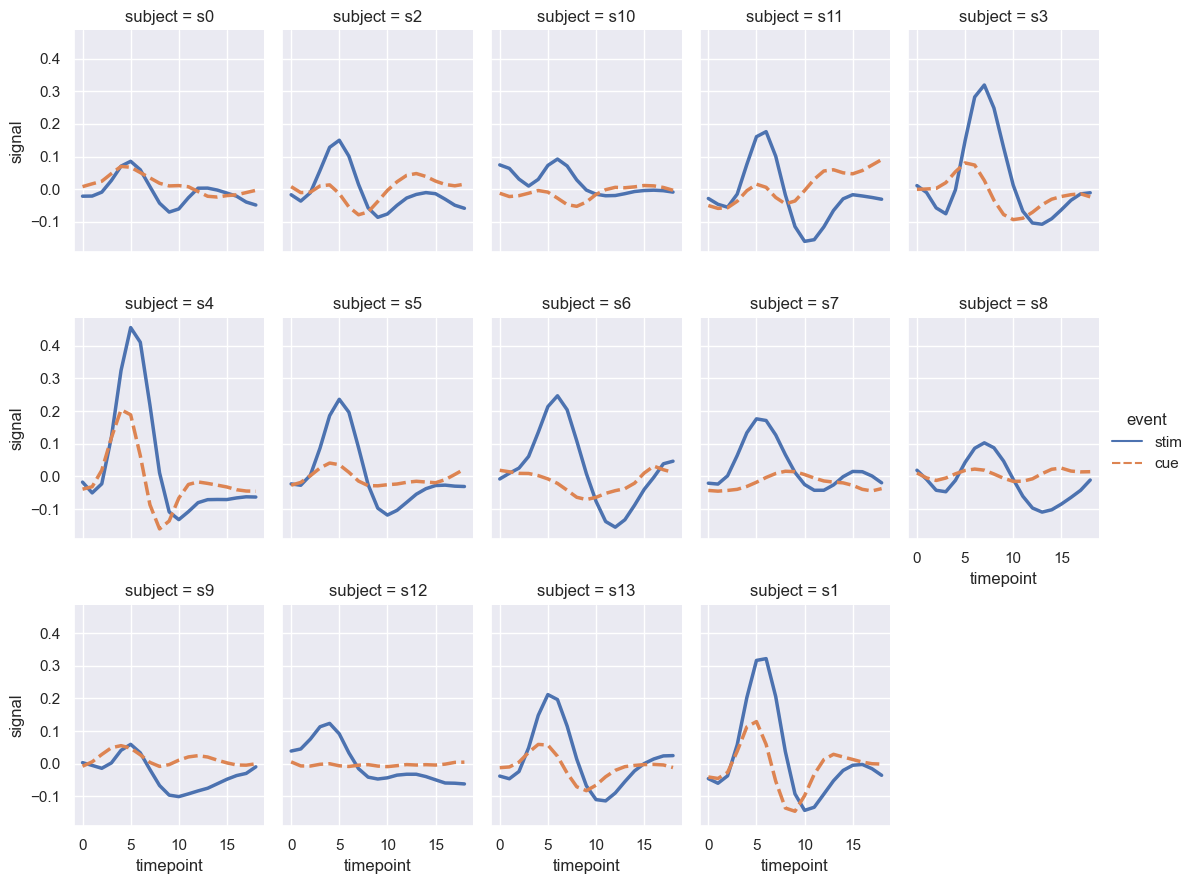

In [102]:
sns.relplot(
    data=fmri.query("region == 'frontal'"), kind="line",
    x="timepoint", y="signal", hue="event", style="event",
    col="subject", col_wrap=5,
    height=3, aspect=.75, linewidth=2.5,
)